<a href="https://colab.research.google.com/github/SNKonara/NLP-lec/blob/main/model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Simple model training

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

In [3]:
# 1. Load dataset
df = pd.read_csv('/content/combined_sentiment_data.csv')
#

In [4]:
#Check first row
df.head()

,sentence,sentiment
0,So there is no way for me to plug it in here i...,negative
1,"Good case, Excellent value.",positive
2,Great for the jawbone.,positive
3,Tied to charger for conversations lasting more...,negative
4,The mic is great.,positive


In [5]:
# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(df['sentence'], df['sentiment'], test_size=0.2, random_state=42)

In [6]:
# 3. Build pipeline (TF-IDF + Naive Bayes)
model = make_pipeline(CountVectorizer(), MultinomialNB())

In [7]:
# 4. Train model
model.fit(X_train, y_train)

Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('multinomialnb', MultinomialNB())])

In [8]:
# 5. Predict
y_pred = model.predict(X_test)

In [9]:
# 6. Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.82      0.84      0.83       334
    positive       0.83      0.81      0.82       328

    accuracy                           0.82       662
   macro avg       0.82      0.82      0.82       662
weighted avg       0.82      0.82      0.82       662



In [11]:
# 7. Try new sample
new_sample = ["I love this product!"]
prediction =model.predict(new_sample)
print(prediction)

['positive']


In [13]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [14]:
def plot_results(y_test, y_pred, model_name):
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

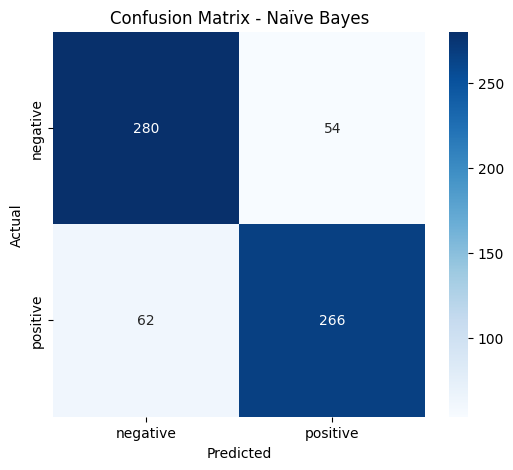

In [15]:
plot_results(y_test, y_pred, "Naïve Bayes")

In [16]:
#...............Logistic regression + TD-IDF................

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
# 1. import dataset
# 2. split dataset
# already done

In [20]:
# 3. Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))  # unigrams + bigrams
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
# 4. Train Logistic Regression
model = LogisticRegression(max_iter=1000, solver="lbfgs")
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [22]:
# 5. Predict
y_pred = model.predict(X_test_tfidf)

In [23]:
# 6. Evaluate
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.82      0.81      0.81       334
    positive       0.81      0.82      0.81       328

    accuracy                           0.81       662
   macro avg       0.81      0.81      0.81       662
weighted avg       0.81      0.81      0.81       662



In [24]:
# 7. Try new sample
new_sample = ["I love this product!"]
prediction = model.predict(tfidf.transform(new_sample))
print("Prediction:", prediction[0])

Prediction: positive


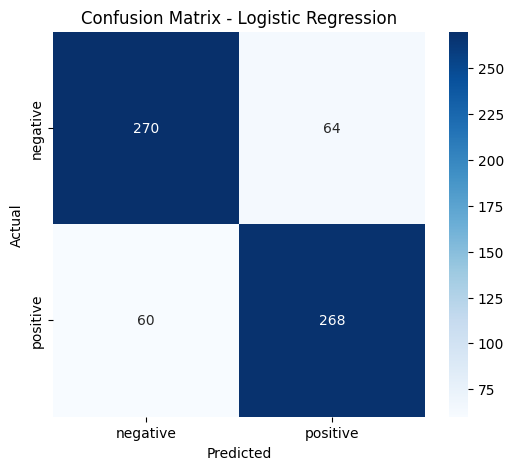

In [26]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, solver="lbfgs")
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)


# Confusion Matrix Plot
model = lr_model   # logistic regression model has .classes_
plot_results(y_test, y_pred_lr, "Logistic Regression")